In [13]:
# backend.py

from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
import requests
import os

In [2]:
load_dotenv()

True

In [3]:
llm1 = ChatGroq(model="openai/gpt-oss-120b",
    api_key=os.getenv(
        "GROQ_API_KEY"
))

In [4]:
sub_llm = ChatGroq(model="llama-3.3-70b-versatile",
    api_key=os.getenv(
        "GROQ_API_KEY"
))

In [14]:
class ParentState(TypedDict):
    topic: str
    exp: str
    translation: str

In [25]:
def translation_node(state: ParentState):
    prompt = f"Generate the chinese translation of the following explanation:\n\nExplanation: \n {state['exp']}"

    response = sub_llm.invoke(prompt)

    return {
        'translation': response.content
    }

In [26]:
builder2 = StateGraph(ParentState)

builder2.add_node('translation_node', translation_node)

builder2.add_edge(START, 'translation_node')

builder2.add_edge('translation_node', END)


subgraph = builder2.compile()

In [27]:
def chat_node(state: ParentState):
    prompt = f"Explain the following topic in funniest way:\n\ntopic:\n{state['topic']}"

    response = llm1.invoke(prompt)

    return {
        'exp': response.content
    }

In [28]:
builder1 = StateGraph(ParentState)

builder1.add_node('chat_node', chat_node)
builder1.add_node('translation', subgraph)

builder1.add_edge(START, 'chat_node')
builder1.add_edge('chat_node', 'translation')
builder1.add_edge('translation', END)


graph = builder1.compile()



In [20]:
from IPython.display import Image, display

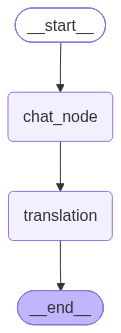

In [29]:
display(Image(graph.get_graph().draw_mermaid_png()))

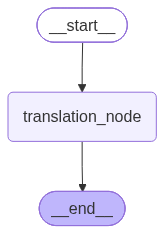

In [30]:
display(Image(subgraph.get_graph().draw_mermaid_png()))

In [31]:
result = graph.invoke(
    {
        'topic': 'AI'
    }
)

print(result['translation'])

## 机器人：那个成长太快的书呆子（现在已经接管了整个房子）

### 1. “什么是 AI？”
把 AI 想象成高中时那个总是摆弄魔方、化学套件和烤面包机的孩子。他会盯着一个问题，按几下按钮，突然整个自助餐厅都有精确时序的披萨送达。在技术术语中，**人工智能**是一堆算法（孩子的大脑），它们从数据（无尽的零食）中学习，然后做出决定——有时是天才级的，有时是“为什么你把菠萝放在我的披萨上？”的水平。

> **TL;DR：** AI = 一个超级好奇的机器人，它以数据为早餐，以预测为晚餐。

---

### 2. “它是如何工作的？（剧透：它不是魔法，它是数学魔术）”

| 人脑（类似） | AI 对应物 | 它实际上做了什么 |
| --- | --- | --- |
| **神经元** – 当你看到猫表情包时会激发的微小细胞 | **人工神经元** – 当数字大于 0.5 时会激发的微小数学函数 | 它们将加权输入相加，应用一个“激活”函数，并说“我的天，这可能是一只猫”。 |
| **突触** – 告诉神经元谁该说话的电线 | **权重** – 决定一个神经元的意见对另一个神经元有多重要的数字 | 如果权重很大，信号会被放大；如果它很小，那就是耳语。 |
| **学习** – 你重复“法国的首都是巴黎”，直到它被记住 | **训练** – 算法反复猜测，得到“错误/正确”的反馈，并且每次都会根据反馈微调权重 | 它基本上是 AI 版本的“再试一次，直到你的父母不再告诉你打扫你的房间”。 |

#### “神经网络”魔术
1. **给它数据**（例如，成千上万张狗戴墨镜的照片）。  
2. **让它猜测**（也许它以为一只贵宾犬是一只“毛茸茸的土豆”）。  
3. **告诉它“不对”**（损失函数大喊“你错了！”）。  
4. **调整权重**（就像幼儿学习堆积积木一样）。  
5. **重复**，直到它可以从 10 米外识别出一只戴墨镜的狗*并*写一首关于它的俳句。

---

### 3. AI 类型：从“可爱的小狗”到“终结者轻度版”

| 级别 | 名称 | 它能做什么 | 它在现实生活中是如何工作的 |
| --- | --- | --- | --- |
| **狭义 AI**（又称“专家”） | *独轮车* | 战胜你在国际象棋中，推荐猫视频，将“

In [32]:
print(result['exp'])

## 🤖 AI: The Nerdy Kid Who Grew Up Too Fast (and Now Runs the House)

### 1. “What is AI, anyway?”
Think of AI as that kid in high‑school who was *always* tinkering with a Rubik’s cube, a chemistry set, and a toaster at the same time. He’d stare at a problem, mash a few buttons, and suddenly the whole cafeteria had a perfectly timed pizza delivery. In tech‑speak, **Artificial Intelligence** is a bunch of algorithms (the kid’s brain) that learn from data (the endless snack‑stashes) and then make decisions—sometimes brilliant, sometimes… “why did you put a pineapple on my pizza?”‑level.

> **TL;DR:** AI = a super‑curious robot that eats data for breakfast and spits out predictions for dinner.

---

### 2. “How does it actually work? (Spoiler: It’s not magic, it’s math‑magic)”

| Human Brain (ish) | AI Counterpart | What It Actually Does |
|-------------------|----------------|-----------------------|
| **Neurons** – tiny cells that fire when you see a cat meme | **Artificial Neurons** – 